# Explore Data

In [1]:
import xarray as xr
import yaml

from pathlib import Path
from matplotlib import pyplot as plt

from temp_humidity_index.settings import load_settings

In [63]:
settings = load_settings()
raw_nc_file = settings.raw_nc_path
wet_bulb_nc_file = settings.wet_bulb_nc_path
thi_nc_file = settings.thi_nc_path

In [64]:
# Load the initial dataset before adding wet bulb temperature. 
ds = xr.open_dataset(raw_nc_file)
ds

<xarray.Dataset> Size: 112MB
Dimensions:            (step: 9, latitude: 721, longitude: 1440)
Coordinates:
  * step               (step) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days ...
    valid_time         (step) datetime64[ns] 72B ...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    time               datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables:
    t2m                (step, latitude, longitude) float32 37MB ...
    d2m                (step, latitude, longitude) float32 37MB ...
    msl                (step, latitude, longitude) float32 37MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-02T10:35 GRIB to CDM+CF via cfgrib-0.9.1...

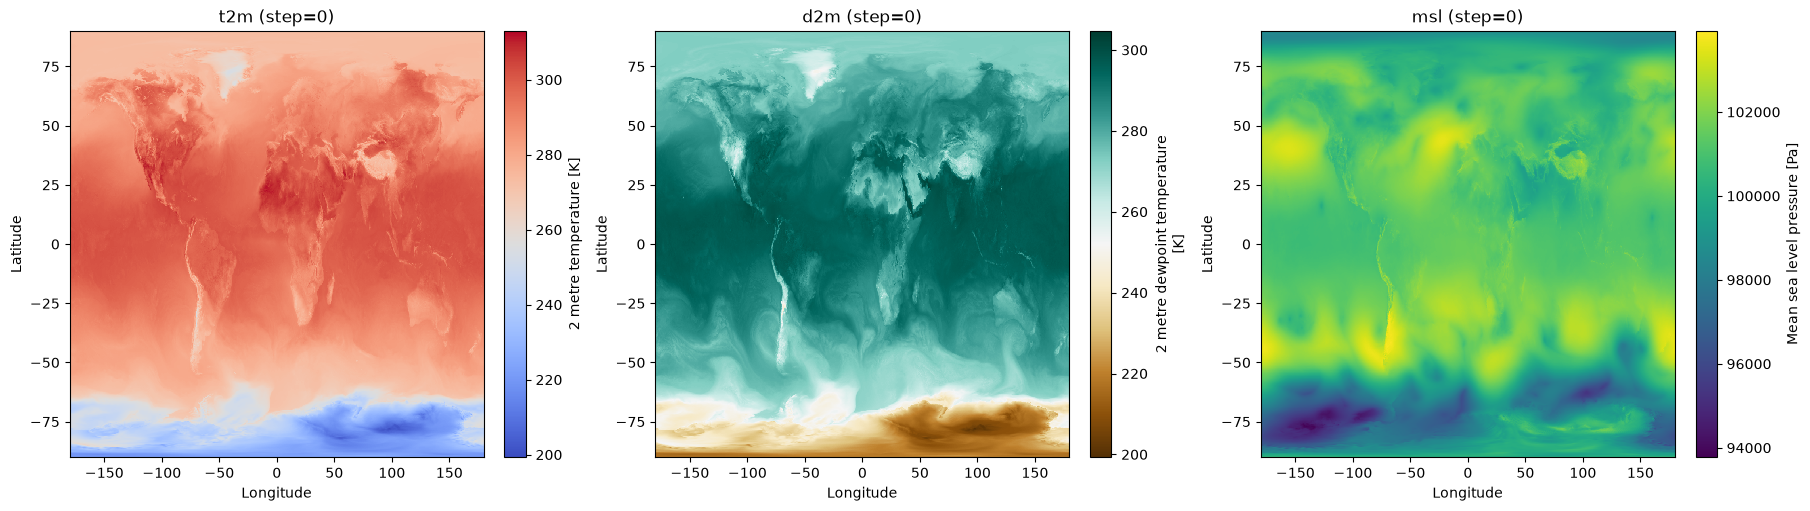

In [65]:
# Plot t2m, d2m and sp for the first available time/step indices
indexers = {}
if "time" in ds.dims:
    indexers["time"] = 0
if "step" in ds.dims:
    indexers["step"] = 0

first_slice = ds.isel(**indexers)

label_parts = [f"{k}=0" for k in ("time", "step") if k in indexers]
label = ", ".join(label_parts) if label_parts else "first slice"

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

first_slice["t2m"].plot(ax=axes[0], cmap="coolwarm")
axes[0].set_title(f"t2m ({label})")

first_slice["d2m"].plot(ax=axes[1], cmap="BrBG")
axes[1].set_title(f"d2m ({label})")

first_slice["msl"].plot(ax=axes[2], cmap="viridis")
axes[2].set_title(f"msl ({label})")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.show()

In [66]:
# Load the dataset with wet bulb temperature added
ds = xr.open_dataset(wet_bulb_nc_file)
ds

<xarray.Dataset> Size: 150MB
Dimensions:            (step: 9, latitude: 721, longitude: 1440)
Coordinates:
  * step               (step) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days ...
    valid_time         (step) datetime64[ns] 72B ...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    time               datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables:
    t2m                (step, latitude, longitude) float32 37MB ...
    d2m                (step, latitude, longitude) float32 37MB ...
    msl                (step, latitude, longitude) float32 37MB ...
    tw                 (step, latitude, longitude) float32 37MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-02T10:35 GRIB to CDM+CF via cfgrib-0.9.1...

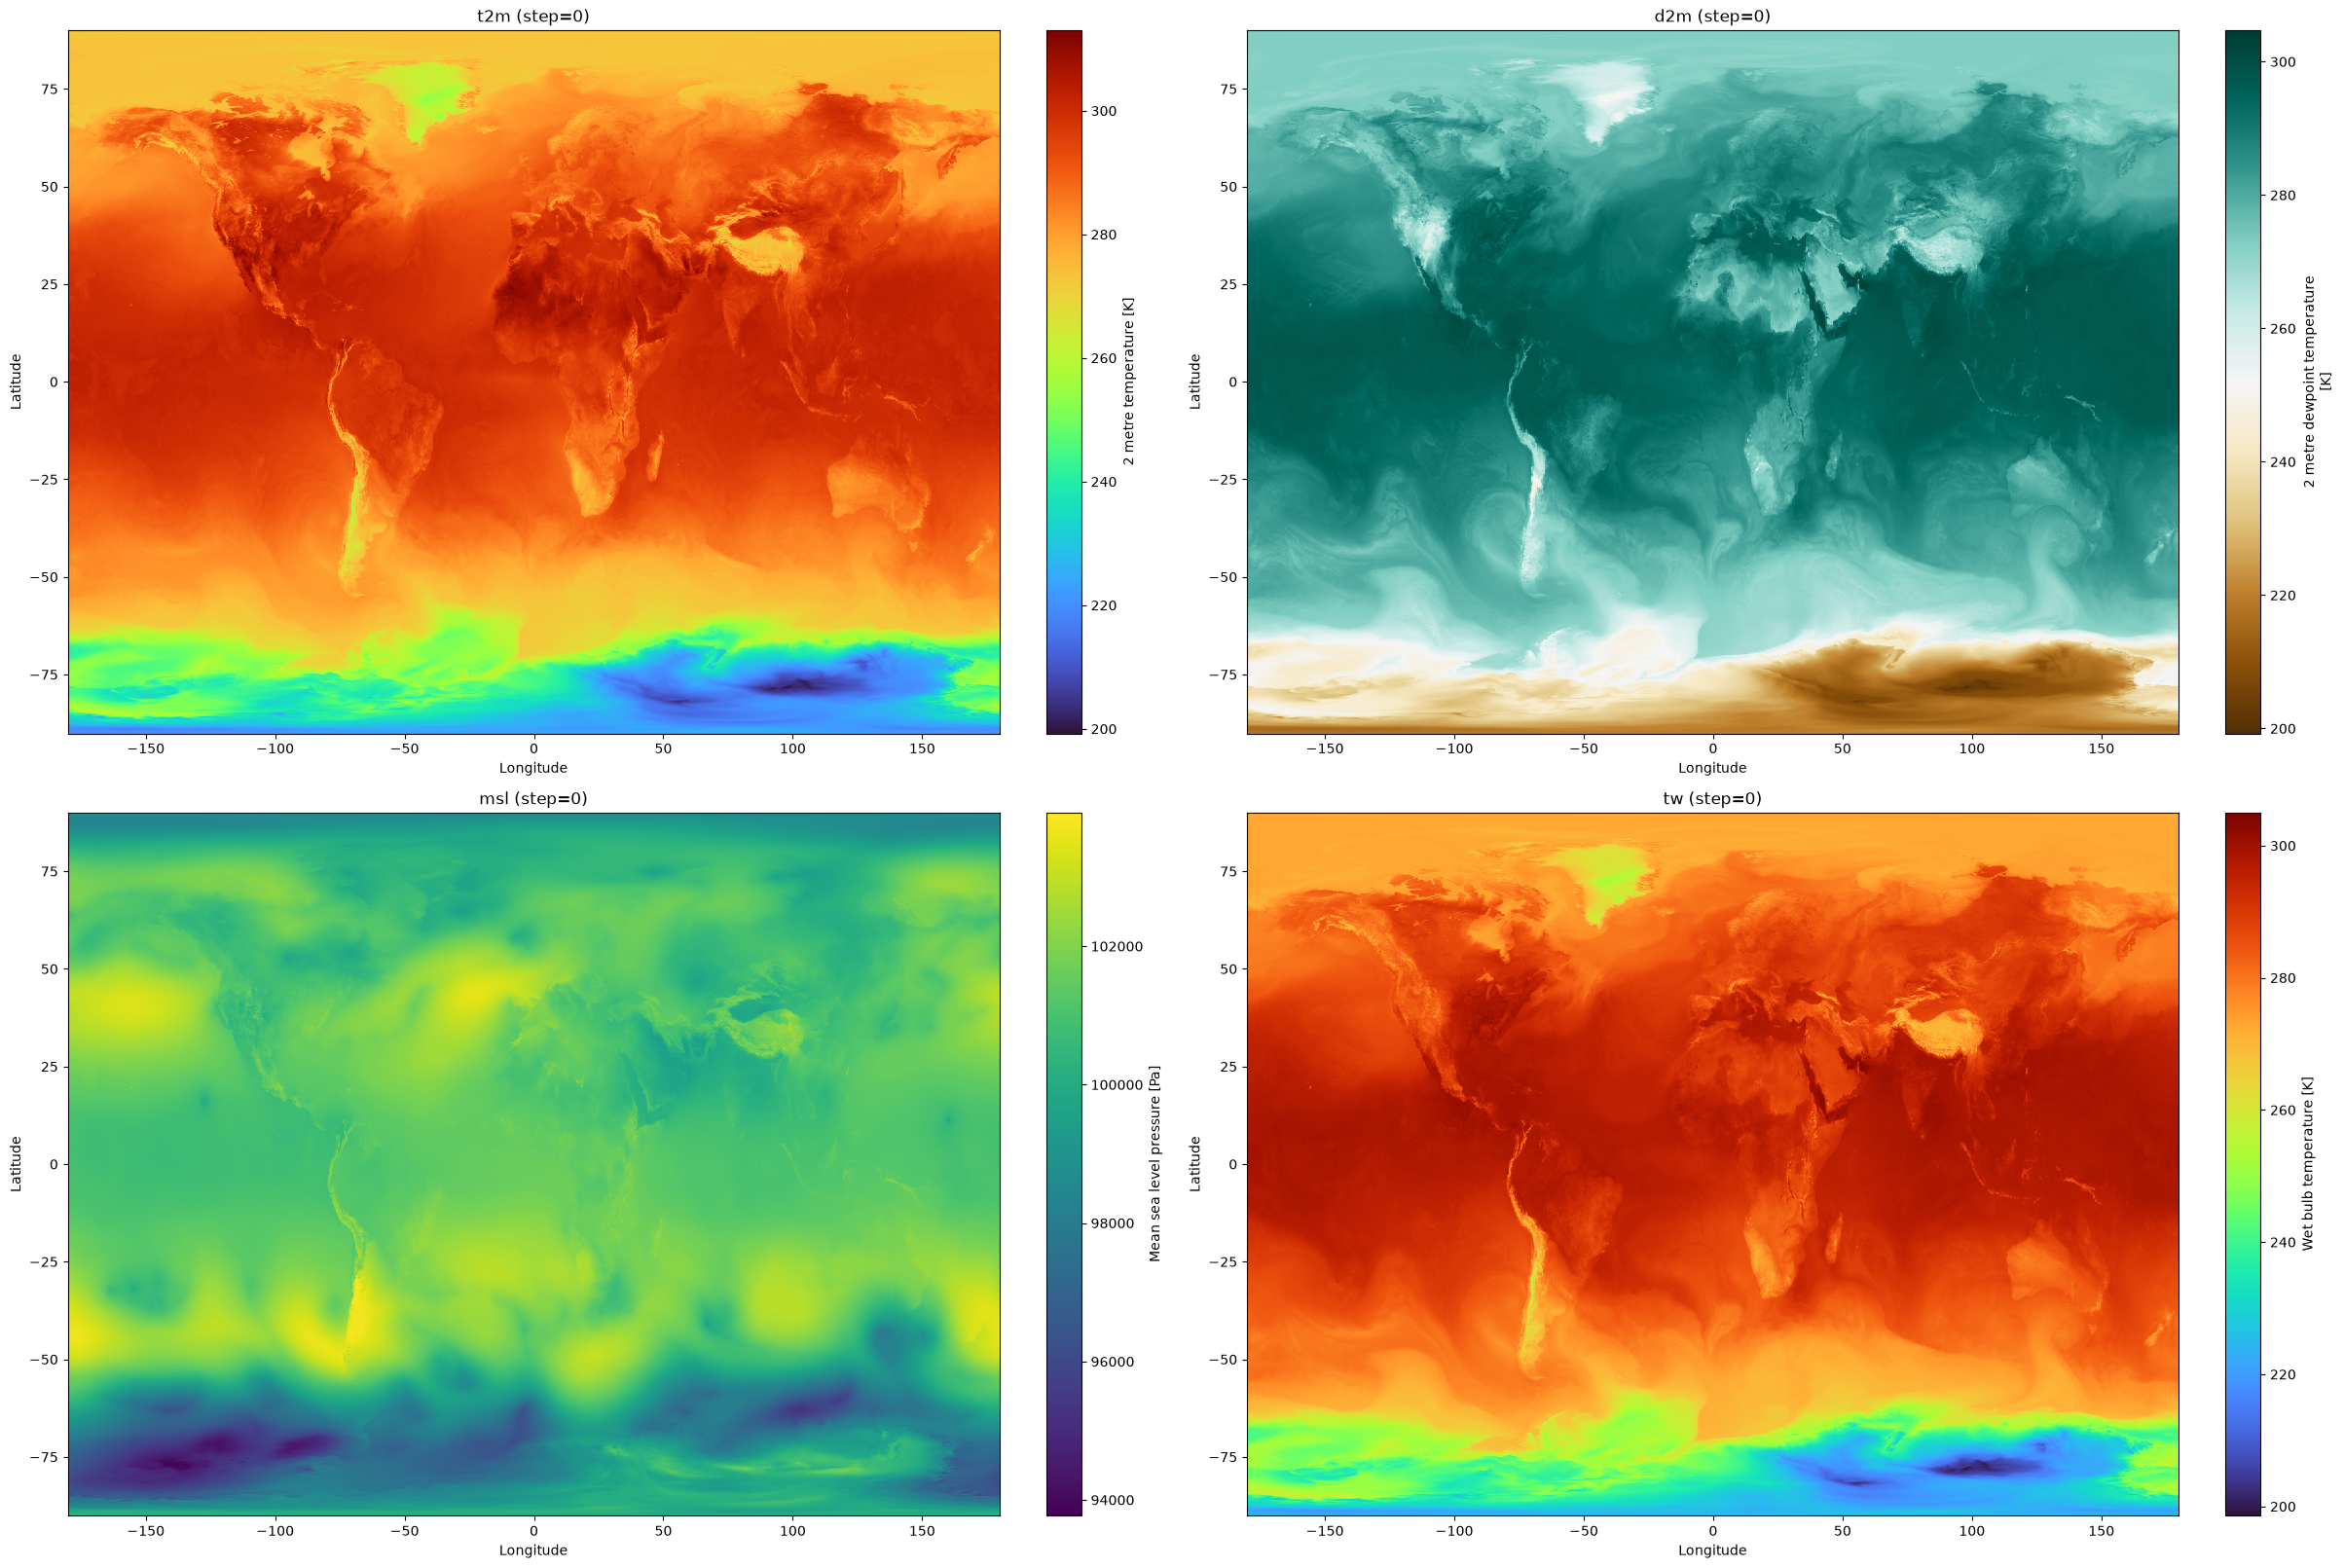

In [67]:
# Plot t2m, d2m, msl, and tw for the first available time/step indices
indexers = {}
if "time" in ds.dims:
    indexers["time"] = 0
if "step" in ds.dims:
    indexers["step"] = 0

first_slice = ds.isel(**indexers)

label_parts = [f"{k}=0" for k in ("time", "step") if k in indexers]
label = ", ".join(label_parts) if label_parts else "first slice"

fig, axes = plt.subplots(2, 2, figsize=(24, 16), constrained_layout=True)
axes = axes.flatten()

first_slice["t2m"].plot(ax=axes[0], cmap="turbo")
axes[0].set_title(f"t2m ({label})")

first_slice["d2m"].plot(ax=axes[1], cmap="BrBG")
axes[1].set_title(f"d2m ({label})")

first_slice["msl"].plot(ax=axes[2], cmap="viridis")
axes[2].set_title(f"msl ({label})")

first_slice["tw"].plot(ax=axes[3], cmap="turbo")
axes[3].set_title(f"tw ({label})")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.show()

In [89]:
# Load the dataset with wet bulb temperature added
ds = xr.open_dataset(thi_nc_file)
ds

<xarray.Dataset> Size: 37MB
Dimensions:            (step: 9, latitude: 721, longitude: 1440)
Coordinates:
  * step               (step) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days ...
    valid_time         (step) datetime64[ns] 72B ...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    time               datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables:
    thi                (step, latitude, longitude) float32 37MB ...

Mean THI over whole first slice: 10.72 °C
Min THI over whole first slice: -54.66 °C
Max THI over whole first slice: 33.69 °C


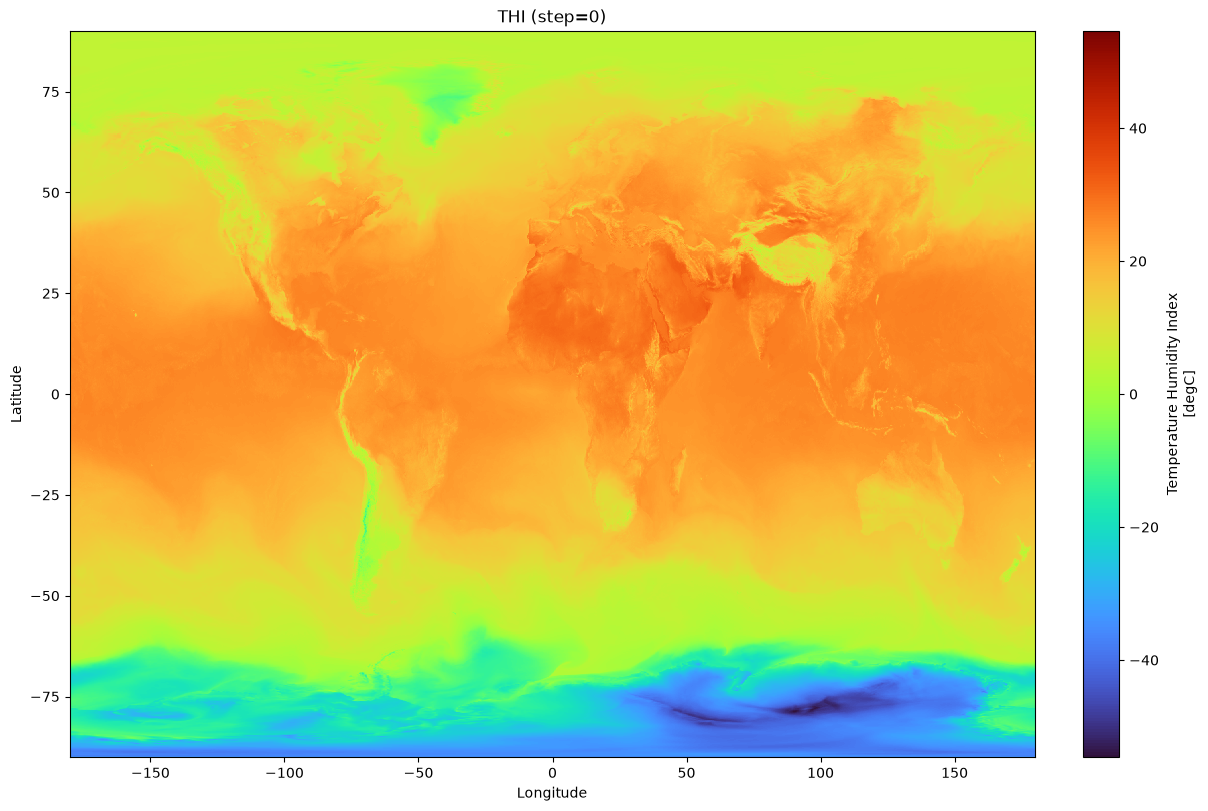

In [90]:
# Plot THI for the first available time/step indices
indexers = {}
if "time" in ds.dims:
    indexers["time"] = 0
if "step" in ds.dims:
    indexers["step"] = 2    # mid day

first_slice = ds.isel(**indexers)

# Print stats to check that THI values are reasonable and within expected range
mean_thi = first_slice["thi"].mean(skipna=True).item()
min_thi = first_slice["thi"].min(skipna=True).item()
max_thi = first_slice["thi"].max(skipna=True).item()
print(f"Mean THI over whole first slice: {mean_thi:.2f} °C")
print(f"Min THI over whole first slice: {min_thi:.2f} °C")
print(f"Max THI over whole first slice: {max_thi:.2f} °C")

label_parts = [f"{k}=0" for k in ("time", "step") if k in indexers]
label = ", ".join(label_parts) if label_parts else "first slice"

fig, axes = plt.subplots(1, 1, figsize=(12, 8), constrained_layout=True)

first_slice["thi"].plot(ax=axes, cmap="turbo")
axes.set_title(f"THI ({label})")

axes.set_xlabel("Longitude")
axes.set_ylabel("Latitude")

plt.show()

Saved: /Users/johnpill/DATA/temp_humidity_index/charts/ifs_heat_stress_20260702_000.png


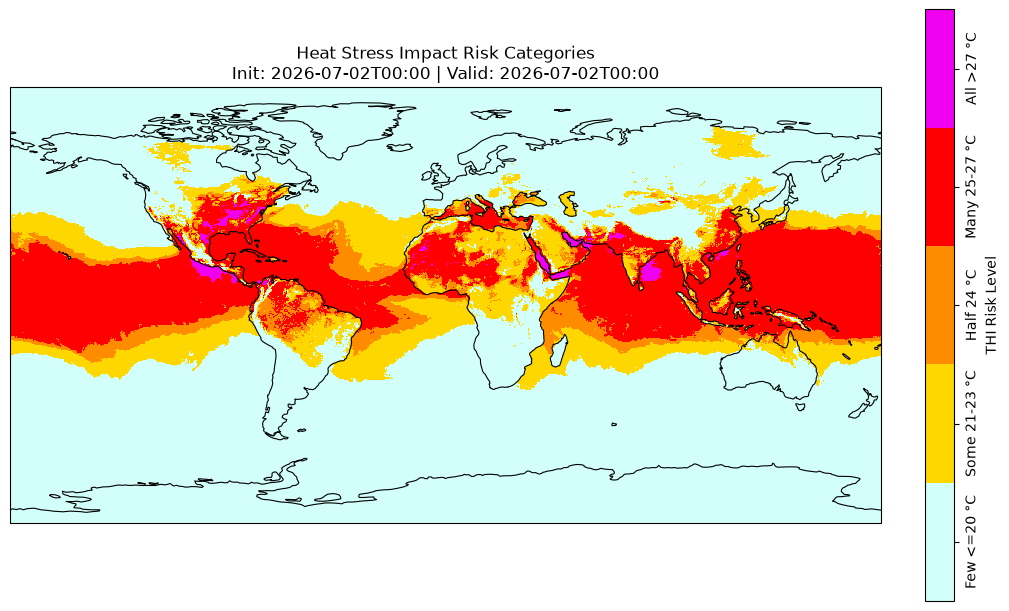

Saved: /Users/johnpill/DATA/temp_humidity_index/charts/ifs_heat_stress_20260702_006.png


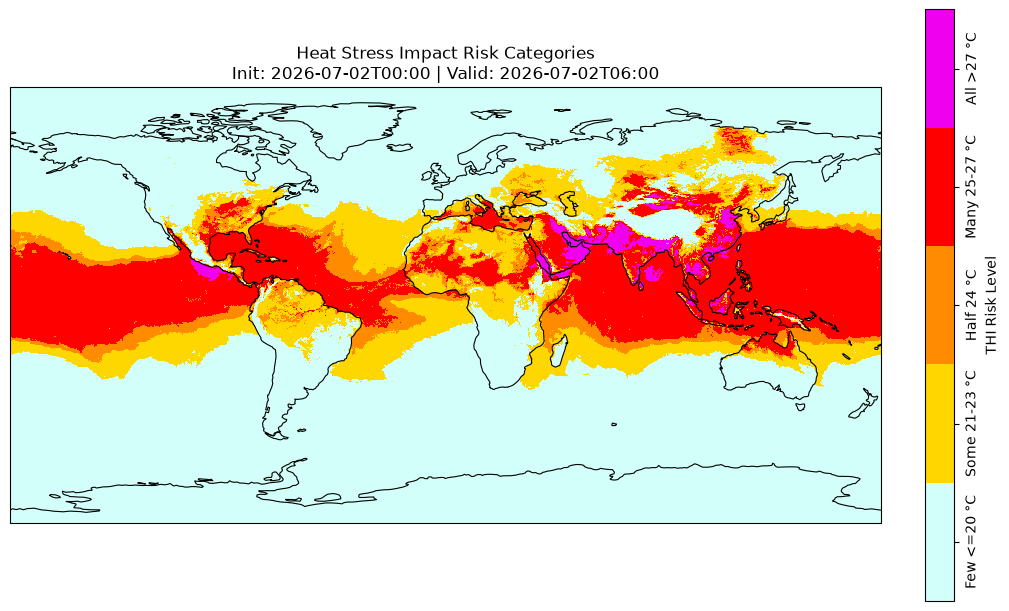

Saved: /Users/johnpill/DATA/temp_humidity_index/charts/ifs_heat_stress_20260702_012.png


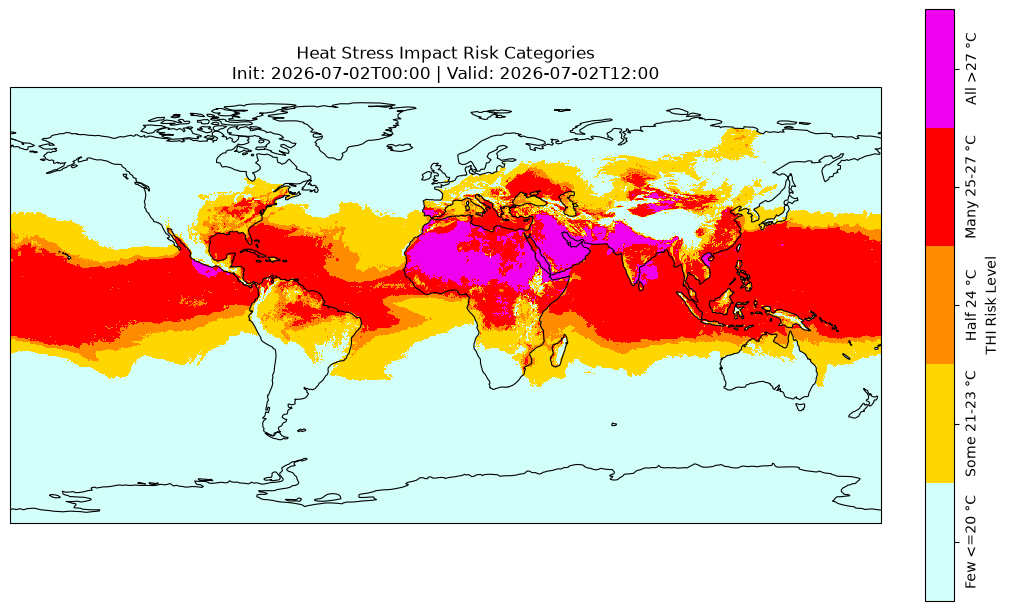

Saved: /Users/johnpill/DATA/temp_humidity_index/charts/ifs_heat_stress_20260702_018.png


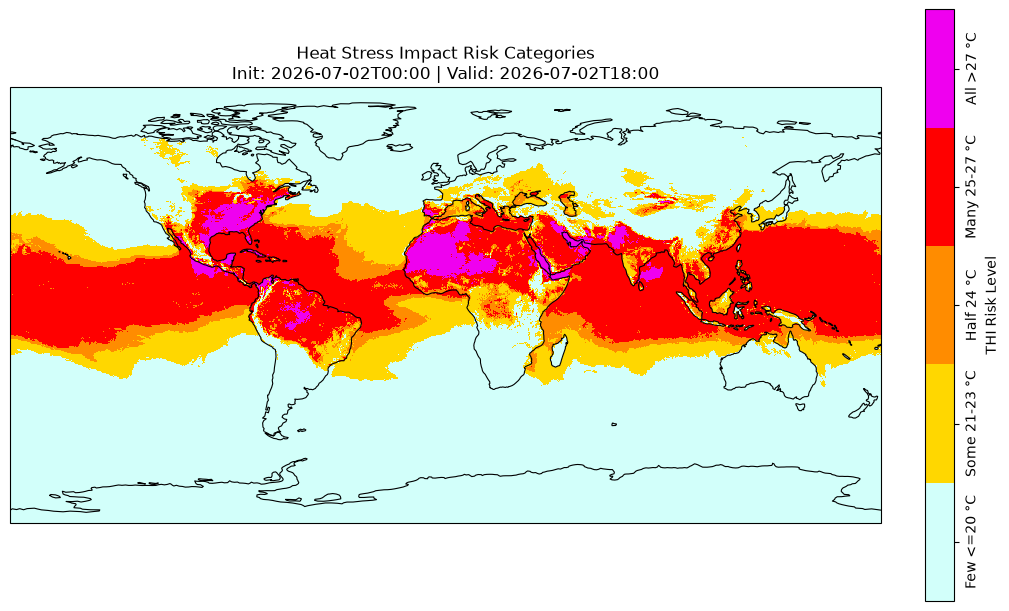

Saved: /Users/johnpill/DATA/temp_humidity_index/charts/ifs_heat_stress_20260702_024.png


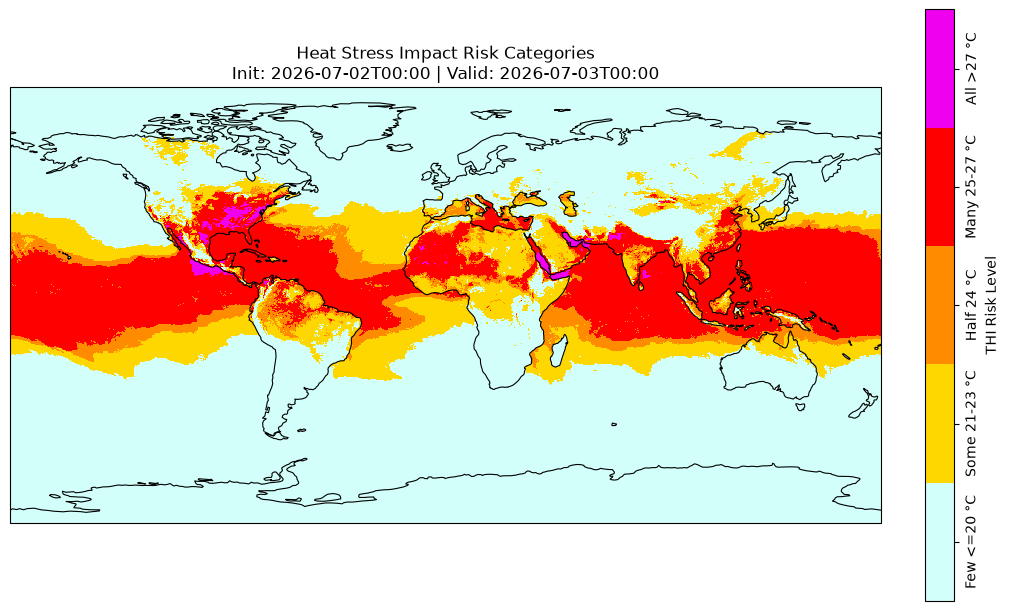

Saved: /Users/johnpill/DATA/temp_humidity_index/charts/ifs_heat_stress_20260702_030.png


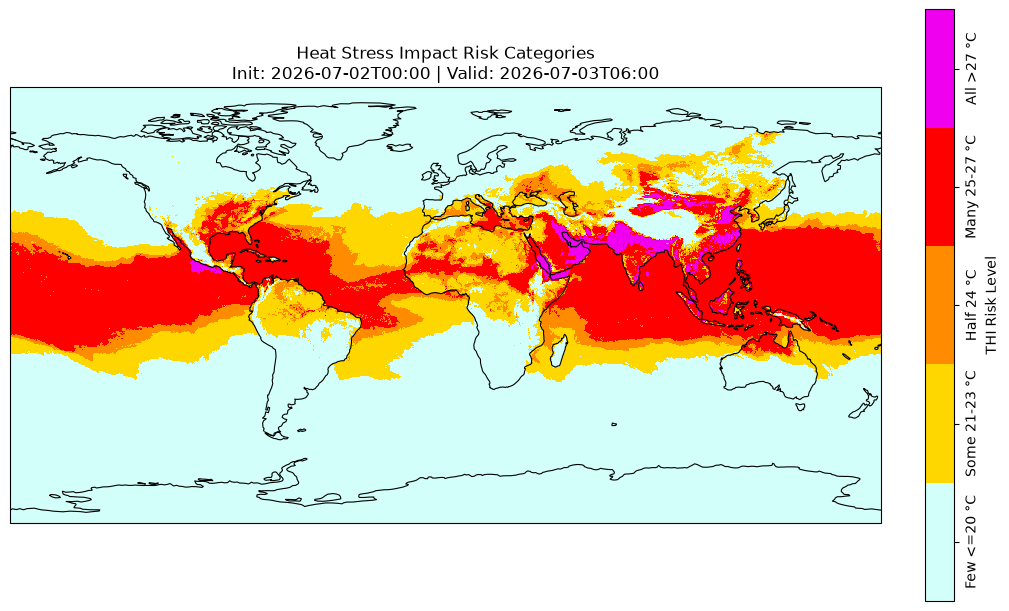

Saved: /Users/johnpill/DATA/temp_humidity_index/charts/ifs_heat_stress_20260702_036.png


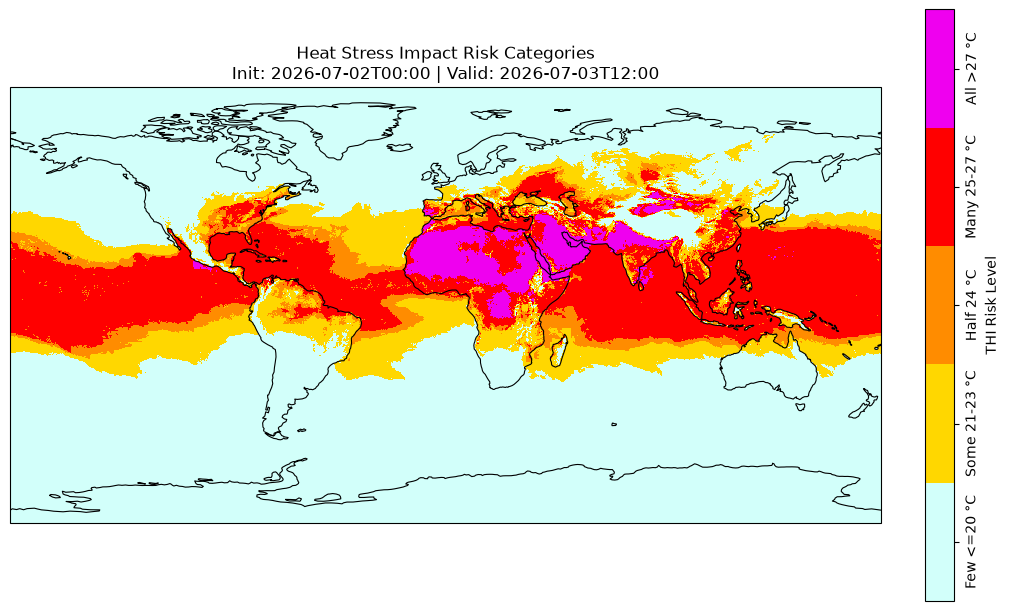

Saved: /Users/johnpill/DATA/temp_humidity_index/charts/ifs_heat_stress_20260702_042.png


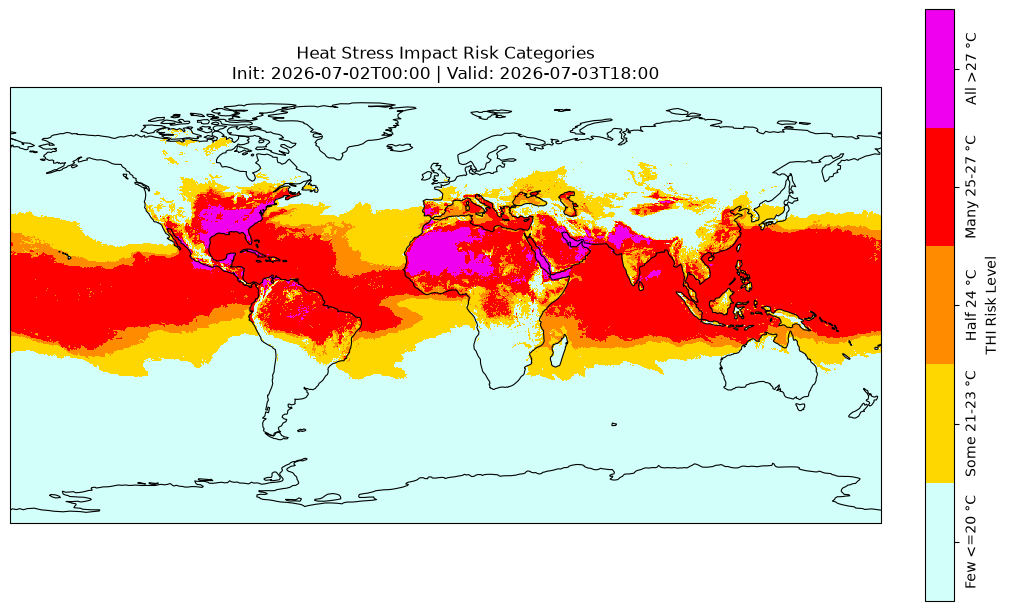

Saved: /Users/johnpill/DATA/temp_humidity_index/charts/ifs_heat_stress_20260702_048.png


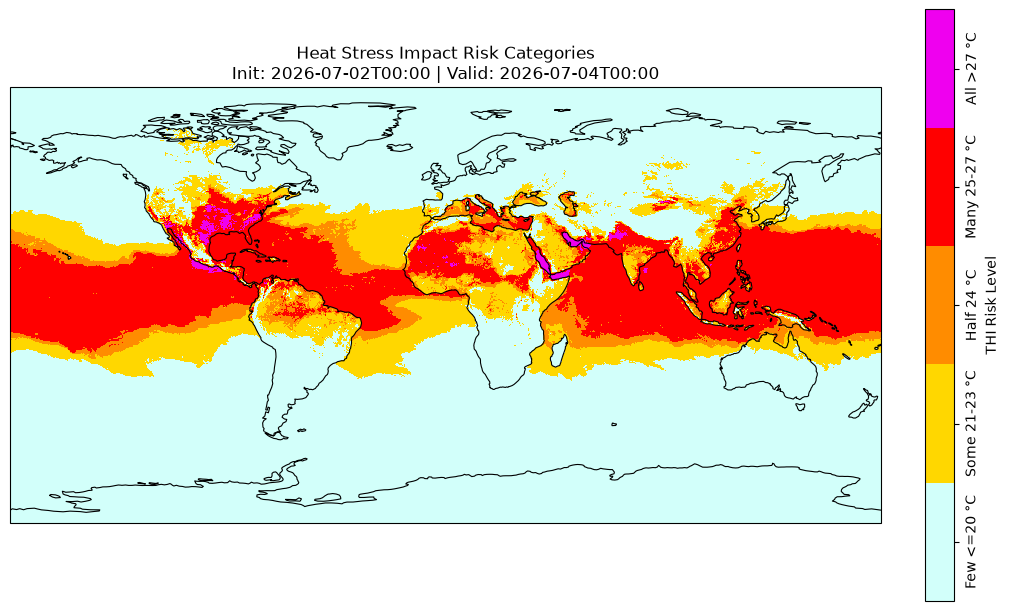

In [ ]:
import numpy as np
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap

ds_thi = xr.open_dataset(thi_nc_file)

# Output directory for images
output_dir = Path(settings.paths.charts_dir)
output_dir.mkdir(parents=True, exist_ok=True)

# THI category thresholds and labels
# Interview pack table seems incorrect at <20c, so we use <=20c for "Few".
bins = [-np.inf, 20, 23, 24, 27, np.inf]
tick_labels = ["Few <=20 °C", "Some 21-23 °C", "Half 24 °C", "Many 25-27 °C", "All >27 °C"]

# Category colors mapped to indices 0..4
cmap = ListedColormap(["#D2FFFA", "#FFD700", "#FF8C00", "#FF0000", "#EF00EF"])
# Missing values (including <20) are transparent
cmap.set_bad((1, 1, 1, 0))

# Model initialization time
init_val = None
if "time" in ds_thi.coords:
    time_coord = ds_thi["time"]
    if "time" in time_coord.dims:
        init_val = time_coord.isel(time=0).values
    else:
        init_val = time_coord.values
    init_str = np.datetime_as_string(np.datetime64(init_val), unit="m")
    init_date_str = np.datetime_as_string(np.datetime64(init_val), unit="D").replace("-", "")
else:
    init_str = "N/A"
    init_date_str = "unknown"

# Loop through all steps (or a single slice if no step dimension)
if "step" in ds_thi.dims:
    step_indices = range(ds_thi.sizes["step"])
else:
    step_indices = [None]

for step_idx in step_indices:
    indexers = {}
    if "time" in ds_thi.dims:
        indexers["time"] = 0
    if step_idx is not None:
        indexers["step"] = step_idx

    thi_slice = ds_thi["thi"].isel(**indexers)

    # Determine validity time for this slice
    if "valid_time" in ds_thi.coords:
        vt = ds_thi["valid_time"]
        vt_indexers = {}
        if "time" in vt.dims:
            vt_indexers["time"] = 0
        if "step" in vt.dims and step_idx is not None:
            vt_indexers["step"] = step_idx
        valid_val = vt.isel(**vt_indexers).values if vt_indexers else vt.values
    elif init_val is not None and "step" in ds_thi.coords and step_idx is not None:
        valid_val = np.datetime64(init_val) + ds_thi["step"].isel(step=step_idx).values
    elif init_val is not None:
        valid_val = np.datetime64(init_val)
    else:
        valid_val = None

    valid_str = (
        np.datetime_as_string(np.datetime64(valid_val), unit="m")
        if valid_val is not None
        else "N/A"
    )

    # Step in hours for filename suffix XXX
    if step_idx is not None and "step" in ds_thi.coords:
        step_val = ds_thi["step"].isel(step=step_idx).values
        if np.issubdtype(np.asarray(step_val).dtype, np.timedelta64):
            step_hours = int(step_val / np.timedelta64(1, "h"))
        else:
            step_hours = int(step_val)
    else:
        step_hours = 0
    step_str = f"{step_hours:03d}"

    # Convert THI values to category indices so colorbar labels are centered by construction
    vals = thi_slice.values
    vals_i = np.rint(vals)

    cats = np.digitize(vals_i, bins=bins, right=True) - 1
    cats = np.where(np.isfinite(vals), cats, np.nan)  # keep NaN handling
    cat_da = thi_slice.copy(data=cats.astype(float))

    fig, ax = plt.subplots(
        figsize=(10, 6),
        constrained_layout=True,
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    ax.add_feature(cfeature.OCEAN, facecolor="#7EC8E3", edgecolor="none", zorder=0)

    mappable = cat_da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=-0.5,
        vmax=len(bins) - 1 - 0.5,
        add_colorbar=True,
        cbar_kwargs={
            "ticks": list(range(len(bins) - 1)),
            "label": "THI Risk Level",
        },
    )
    mappable.colorbar.set_ticklabels(tick_labels)
    for lbl in mappable.colorbar.ax.get_yticklabels():
        lbl.set_rotation(90)
        lbl.set_verticalalignment("center")
        lbl.set_horizontalalignment("left")
    mappable.colorbar.ax.tick_params(pad=4)

    ax.coastlines(linewidth=0.8)
    ax.set_title(
        "Heat Stress Impact Risk Categories\n"
        f"Init: {init_str} | Valid: {valid_str}"
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    out_file = output_dir / f"ifs_heat_stress_{init_date_str}_{step_str}.png"
    fig.savefig(out_file, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_file}")

    plt.show()

In [73]:
import numpy as np

# Category order must match your colorbar labels:
# 0=Few, 1=Some, 2=Half, 3=Many, 4=All
labels = ["Few", "Some", "Half", "Many", "All"]

# Use boundaries that match your expected behavior exactly:
# Few: <21, Some: [21,24), Half: [24,25), Many: [25,28), All: >=28
bins = [-np.inf, 21, 24, 25, 28, np.inf]

test_vals = np.array([20.9, 21.0, 22.0, 23.9, 24.0, 24.9, 25.0, 27.9, 28.0])
expected  = np.array([0,    1,    1,    1,    2,    2,    3,    3,    4])

got = np.digitize(test_vals, bins=bins, right=False) - 1

print("value  got   expected")
for v, g, e in zip(test_vals, got, expected):
    print(f"{v:4.1f}  {labels[g]:5s} {labels[e]}")

assert np.array_equal(got, expected), f"Mismatch: got={got}, expected={expected}"
print("Category mapping test passed.")

value  got   expected
20.9  Few   Few
21.0  Some  Some
22.0  Some  Some
23.9  Some  Some
24.0  Half  Half
24.9  Half  Half
25.0  Many  Many
27.9  Many  Many
28.0  All   All
Category mapping test passed.


### Interview Data Table Answers
Calculate answers for the data in the interview table. 

In [ ]:
import numpy as np
import xarray as xr

from temp_humidity_index.calculate.calc_thi import _calculate_thi
from temp_humidity_index.plotting.plot_heat_risk_charts import CMAP, categorise_thi

labels = ["Few", "Some", "Half", "Many", "All"]

# Build labelled dataset:
test_ds = xr.Dataset(
    data_vars={
        "dry_bulb_temp": (
            ["sample"],
            np.array([22.4, 18.6, 26.0, 13.2, 14.6, 34.2], dtype=float),
            {
                "units": "degC",
                "long_name": "Dry bulb temperature",
            }
        ),
        "wet_bulb_temp": (
            ["sample"],
            np.array([10.9, 16.44, 20.5, 9.4, 19.2, 22.8], dtype=float),
            {
                "units": "degC",
                "long_name": "Wet bulb temperature",
            }
        ),
    },
    coords={
        "sample": np.arange(6),
        "date": ("sample", [1, 1, 2, 2, 3, 3]),
        "location": ("sample", ["A", "B", "B", "C", "A", "C"]),
    },
)

# Calculate and add THI
thi = _calculate_thi(test_ds["dry_bulb_temp"], test_ds["wet_bulb_temp"])
test_ds["thi"] = thi

# Categorise THI and add category labels
test_ds["thi_index"] = categorise_thi(test_ds["thi"])
test_ds['category'] = xr.DataArray(
    data=[labels[int(i)] for i in test_ds["thi_index"].values],
    dims=["sample"],
)

display(test_ds)

<xarray.Dataset> Size: 408B
Dimensions:        (sample: 6)
Coordinates:
  * sample         (sample) int64 48B 0 1 2 3 4 5
    date           (sample) int64 48B 1 1 2 2 3 3
    location       (sample) <U1 24B 'A' 'B' 'B' 'C' 'A' 'C'
Data variables:
    dry_bulb_temp  (sample) float64 48B 22.4 18.6 26.0 13.2 14.6 34.2
    wet_bulb_temp  (sample) float64 48B 10.9 16.44 20.5 9.4 19.2 22.8
    thi            (sample) float64 48B 18.12 18.82 23.4 13.84 18.32 27.6
    thi_index      (sample) float64 48B 0.0 0.0 1.0 0.0 0.0 4.0
    category       (sample) <U4 96B 'Few' 'Few' 'Some' 'Few' 'Few' 'All'

In [20]:
df = test_ds.to_dataframe().reset_index()
df = df.drop(columns=["sample"])
df

,dry_bulb_temp,wet_bulb_temp,date,location,thi,thi_index,category
0,22.4,10.90,1,A,18.120,0.0,Few
1,18.6,16.44,1,B,18.816,0.0,Few
2,26.0,20.50,2,B,23.400,1.0,Some
3,13.2,9.40,2,C,13.840,0.0,Few
4,14.6,19.20,3,A,18.320,0.0,Few
5,34.2,22.80,3,C,27.600,4.0,All
